In [283]:
# Connect to Postgres
%matplotlib inline
%pip install xgboost
import os
import psycopg2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.linear_model import Lasso
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc
from scipy.stats import loguniform

def newCursor():
    try:
        connection = psycopg2.connect(
            user=os.environ["DB_USER"],
            host=os.environ["DB_HOST"],
            password=os.environ["DB_PASSWORD"],
            port="5432",
            database=os.environ["DB_DATABASE"]
        )

        cursor = connection.cursor()
        return cursor

    except (Exception, psycopg2.Error) as error:
        print("Error while connecting to PostgreSQL", error)
        return error


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [284]:
# Test database connection

cursor = newCursor()

if isinstance(cursor, psycopg2.extensions.cursor):
    cursor.execute("SELECT version();")
    db_version = cursor.fetchone()
    print("✅ Successfully connected to PostgreSQL")
    print("Database version:", db_version[0])
else:
    print("❌ Connection failed. Please check environment configuration.")


✅ Successfully connected to PostgreSQL
Database version: PostgreSQL 16.8 on x86_64-pc-linux-gnu, compiled by gcc (GCC) 7.3.1 20180712 (Red Hat 7.3.1-17), 64-bit


In [285]:
# Featured Challenge Tables

FEATURED_TABLES = [
    "D01_transactions_2024-01",
    "D01_transactions_2024-02",
    "D01_transactions_2024-03",
    "D01_transactions_2024-04",
    "D01_transactions_2024-05",
    "D01_transactions_2024-06",
    "D01_transactions_2024-07",
    "D01_transactions_2024-08",
    "D01_transactions_2024-09",
    "D01_transactions_2024-10",
    "D01_transactions_2024-11",
    "D01_transactions_2024-12",
    "D02_payment_instruments",
    "D03_settlement_logs",
    "D04_fraud_events",
    "D05_system_outages",
    "D06_psps",
    "D07_access_channels",
    "D08_cross_border_sepa",
    "D09_macro_aggregates",
    "D10_profiles",
]

print("⭐ Featured Tables loaded:", len(FEATURED_TABLES))


⭐ Featured Tables loaded: 21


In [286]:
# Fetch tables and validate featured tables

from collections import defaultdict

c = newCursor()

q = """
SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_type = 'BASE TABLE'
"""
c.execute(q)
records = c.fetchall()

user_records = [
    (schema, table) for schema, table in records
    if schema not in ("pg_catalog", "information_schema")
]

schemas_by_table = defaultdict(list)
for schema, table in user_records:
    schemas_by_table[table].append(schema)

TABLE_LOOKUP = {
    table: f"{schemas[0]}.{table}"
    for table, schemas in schemas_by_table.items()
}

print("🔎 Checking Featured Tables...\n")

found = 0
for table in FEATURED_TABLES:
    if table in TABLE_LOOKUP:
        print(f"✅ {table}")
        found += 1
    else:
        print(f"❌ {table} (not found)")

print(f"\nMatched {found} out of {len(FEATURED_TABLES)} featured tables.")


🔎 Checking Featured Tables...

✅ D01_transactions_2024-01
✅ D01_transactions_2024-02
✅ D01_transactions_2024-03
✅ D01_transactions_2024-04
✅ D01_transactions_2024-05
✅ D01_transactions_2024-06
✅ D01_transactions_2024-07
✅ D01_transactions_2024-08
✅ D01_transactions_2024-09
✅ D01_transactions_2024-10
✅ D01_transactions_2024-11
✅ D01_transactions_2024-12
✅ D02_payment_instruments
✅ D03_settlement_logs
✅ D04_fraud_events
✅ D05_system_outages
✅ D06_psps
✅ D07_access_channels
✅ D08_cross_border_sepa
✅ D09_macro_aggregates
✅ D10_profiles

Matched 21 out of 21 featured tables.


In [287]:
# List all tables

c = newCursor()

q = """
SELECT table_name
FROM information_schema.tables
"""
c.execute(q)
records = c.fetchall()

# Filter out PostgreSQL system tables
user_tables = [
    r[0] for r in records
    if not r[0].startswith("pg_")
]

if not user_tables:
    print("❌ No user tables found.")
else:
    print(f"📚 Total user tables found: {len(user_tables)}\n")
    for table in user_tables:
        print("-", table)


📚 Total user tables found: 691

- q_airport_distance
- stocks_yahoo_finance
- q_ApprovalRequest
- default
- accounts
- card2
- cards
- q_airportdistance
- channel
- audit_log_schema
- clients
- q_approvalrequest
- collations
- information_schema_catalog_name
- applicable_roles
- domain_constraints
- administrable_role_authorizations
- collation_character_set_applicability
- attributes
- character_sets
- column_udt_usage
- check_constraint_routine_usage
- column_column_usage
- check_constraints
- constraint_table_usage
- column_domain_usage
- columns
- column_privileges
- constraint_column_usage
- domain_udt_usage
- domains
- enabled_roles
- key_column_usage
- parameters
- table_privileges
- referential_constraints
- sql_features
- role_column_grants
- routine_column_usage
- routine_privileges
- role_routine_grants
- routine_routine_usage
- routine_sequence_usage
- routine_table_usage
- routines
- schemata
- sequences
- role_table_grants
- table_constraints
- triggers
- tables
- trigger

# Importing the data

In [288]:
# Preview rows from a selected table

from psycopg2 import sql

# ✅ Choose a table
TABLE = "D04_fraud_events"  # change index e.g. FEATURED_TABLES[3]
LIMIT = 1000

if TABLE not in TABLE_LOOKUP:
    raise ValueError(f'❌ Table "{TABLE}" not found. Run Section 2 cells first.')

# Get schema + table name internally
schema, table_name = TABLE_LOOKUP[TABLE].split(".", 1)

c = newCursor()

# Safe query (handles schema + hyphenated table names correctly)
query = sql.SQL("SELECT * FROM {}.{}").format(
    sql.Identifier(schema),
    sql.Identifier(table_name)
)

c.execute(query, (LIMIT,))
rows = c.fetchall()

# Column names
colnames = [desc[0] for desc in c.description]

print(f"📄 Table: {TABLE}")
print(f"Columns ({len(colnames)}): {colnames}\n")
print(f"Showing {min(LIMIT, len(rows))} rows:\n")

# Pretty display if pandas is available
try:
    import pandas as pd
    df = pd.DataFrame(rows, columns=colnames)
    display(df)
except ImportError:
    for r in rows[:5]:
        print(r)
    if len(rows) > 5:
        print(f"\n... ({len(rows)-5} more rows)")


📄 Table: D04_fraud_events
Columns (15): ['event_id', 'transaction_id', 'event_type', 'detection_timestamp', 'risk_score', 'fraud_label', 'fraud_scenario', 'trigger_reason', 'amount_at_risk', 'amount_lost', 'detection_method', 'victim_type', 'resolution_status', 'resolution_date', 'recovery_amount']

Showing 1000 rows:



,event_id,transaction_id,event_type,detection_timestamp,risk_score,fraud_label,fraud_scenario,trigger_reason,amount_at_risk,amount_lost,detection_method,victim_type,resolution_status,resolution_date,recovery_amount
0,FRAUD_00000001,5212dd34-3c0b-497a-847d-508a2e878b90,Fraud_Alert,2024-09-19 23:05:52,0.194,0,None,Anomaly_Detected,90.9,0.0,ML_Model,Consumer,Closed_False_Positive,2024-09-24,0.0
1,FRAUD_00000002,3e740791-73e6-4ac8-a2ca-3b2f91a69442,Fraud_Alert,2024-12-31 00:01:00,0.8083,1,Card_Not_Present,High_Value_Online,83.12,83.12,ML_Model,Consumer,Closed_Confirmed_Fraud,2025-01-02,29.6
2,FRAUD_00000003,3a01ed1b-3457-4601-a6cb-bfdcaaf11a09,Fraud_Alert,2024-10-28 14:47:01,0.7567,1,Card_Not_Present,Geographic_Anomaly,30.46,30.46,Rule_Based,Consumer,Closed_Confirmed_Fraud,2024-11-04,15.18
3,FRAUD_00000004,e3afc758-4258-4806-8d3a-7ddc9e352a93,Fraud_Alert,2024-11-21 00:09:49,0.2338,0,None,Anomaly_Detected,8.69,0.0,ML_Model,Consumer,Closed_False_Positive,2024-11-23,0.0
4,FRAUD_00000005,4f961b8b-60a8-4ed1-9341-9b5d00f9d1d3,Suspicious_Activity,2024-02-16 18:42:18,0.2524,0,None,Anomaly_Detected,5.03,0.0,Customer_Report,Consumer,Closed_False_Positive,2024-02-19,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,FRAUD_00149996,b6ff9eab-0b2e-41d1-958c-c02e7a1bcebf,Fraud_Alert,2024-07-12 04:55:38,0.2588,0,None,Anomaly_Detected,55.87,0.0,Rule_Based,Consumer,Closed_False_Positive,2024-07-13,0.0
149996,FRAUD_00149997,4f07d3c6-8924-4fcc-97f9-79c4ac54e543,Fraud_Alert,2024-02-26 14:38:44,0.4318,0,None,Anomaly_Detected,88.43,0.0,ML_Model,Consumer,Closed_False_Positive,2024-02-29,0.0
149997,FRAUD_00149998,ed6aaca6-4796-4689-b6b1-8058dc5c6a0d,Fraud_Alert,2024-11-08 11:25:09,0.6751,1,Authorised_Push_Payment,Social_Engineering_Indicators,237.21,237.21,Rule_Based,Consumer,Investigating,None,0.0
149998,FRAUD_00149999,47ad684e-efe3-4adb-b716-ed755c3d7cd9,Fraud_Alert,2024-10-16 17:21:45,0.1584,0,None,Anomaly_Detected,373.11,0.0,Rule_Based,Merchant,Closed_False_Positive,2024-10-17,0.0


# Data quality handling

In [289]:
df.dtypes

event_id               object
transaction_id         object
event_type             object
detection_timestamp    object
risk_score             object
fraud_label            object
fraud_scenario         object
trigger_reason         object
amount_at_risk         object
amount_lost            object
detection_method       object
victim_type            object
resolution_status      object
resolution_date        object
recovery_amount        object
dtype: object

In [290]:
unique_resolution_status = df["resolution_status"].unique()
unique_resolution_status

array(['Closed_False_Positive', 'Closed_Confirmed_Fraud',
       'Closed_Recovered', 'Investigating'], dtype=object)

# Checking for duplicate values

In [291]:
"""
Checking for duplicate values
"""
s = df[df.duplicated()]
s

,event_id,transaction_id,event_type,detection_timestamp,risk_score,fraud_label,fraud_scenario,trigger_reason,amount_at_risk,amount_lost,detection_method,victim_type,resolution_status,resolution_date,recovery_amount


# Performing feature selection

In [292]:
df = df.drop(["resolution_status","fraud_scenario","resolution_date","event_id","transaction_id","detection_timestamp","amount_lost","recovery_amount"],axis = 1)
df

,event_type,risk_score,fraud_label,trigger_reason,amount_at_risk,detection_method,victim_type
0,Fraud_Alert,0.194,0,Anomaly_Detected,90.9,ML_Model,Consumer
1,Fraud_Alert,0.8083,1,High_Value_Online,83.12,ML_Model,Consumer
2,Fraud_Alert,0.7567,1,Geographic_Anomaly,30.46,Rule_Based,Consumer
3,Fraud_Alert,0.2338,0,Anomaly_Detected,8.69,ML_Model,Consumer
4,Suspicious_Activity,0.2524,0,Anomaly_Detected,5.03,Customer_Report,Consumer
...,...,...,...,...,...,...,...
149995,Fraud_Alert,0.2588,0,Anomaly_Detected,55.87,Rule_Based,Consumer
149996,Fraud_Alert,0.4318,0,Anomaly_Detected,88.43,ML_Model,Consumer
149997,Fraud_Alert,0.6751,1,Social_Engineering_Indicators,237.21,Rule_Based,Consumer
149998,Fraud_Alert,0.1584,0,Anomaly_Detected,373.11,Rule_Based,Merchant


# Visualizing components of our dataframe

(0.0, 1000.0)

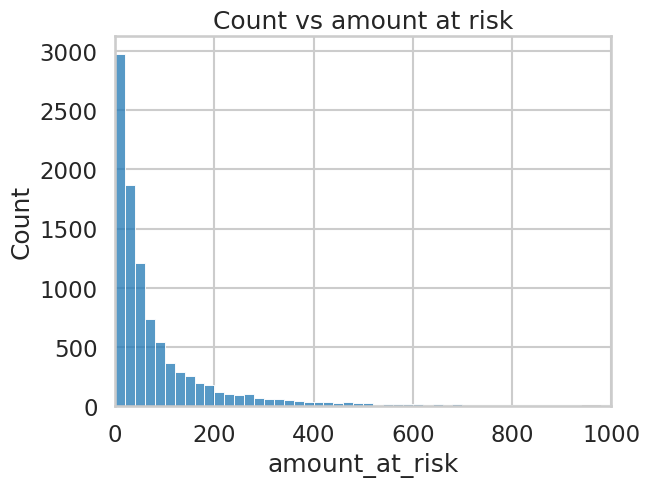

In [293]:
sample_df = df.sample(10000, random_state=42) # sampling components of our very large dataset

sns.histplot(sample_df["amount_at_risk"], bins=50, binrange=(0, 1000))
plt.title("Count vs amount at risk")

plt.xlim(0, 1000)

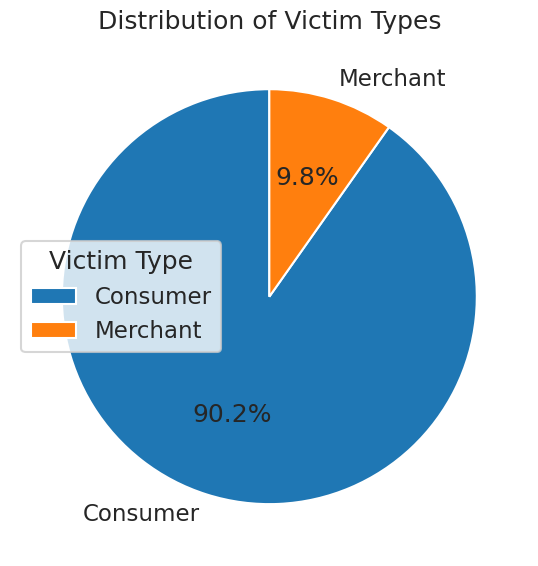

In [294]:
counts = sample_df.groupby('victim_type').size()

plt.figure(figsize=(6, 6))

counts.plot(
    kind='pie',
    autopct='%1.1f%%',     
    startangle=90,         
    ylabel='',             
)

plt.title("Distribution of Victim Types")

plt.legend(
    title="Victim Type",
    loc="best"
)

plt.tight_layout()
plt.show()

<Axes: xlabel='trigger_reason'>

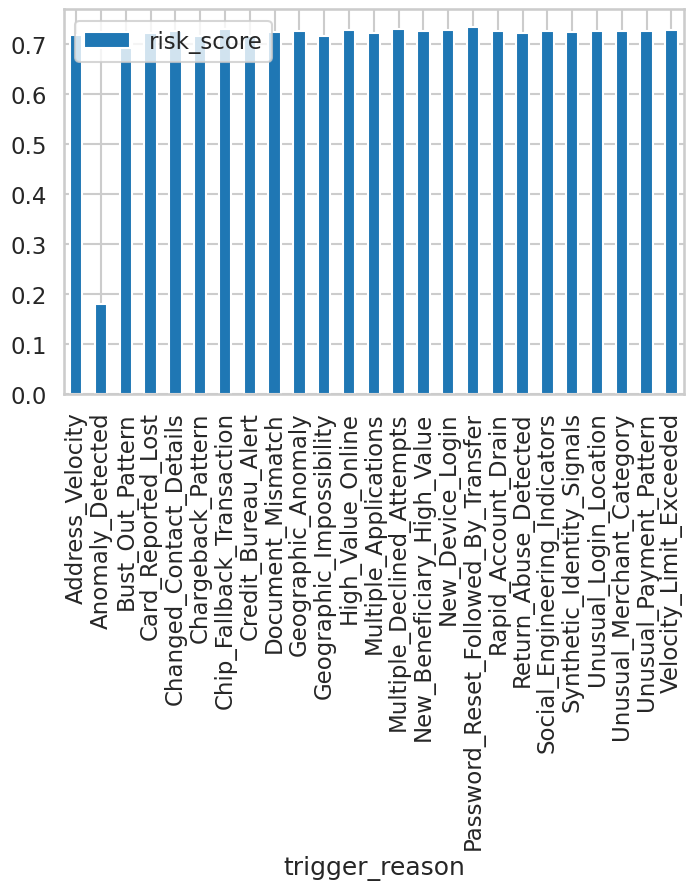

In [295]:
grouped_df = df.groupby("trigger_reason")["risk_score"].mean().reset_index()

grouped_df.plot(
    kind='bar',
    x='trigger_reason',
    y='risk_score',
    figsize=(8,5)
)



# Splitting our data

In [296]:
X = df.drop("fraud_label", axis=1)
y = df["fraud_label"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Performing encoding on training set


In [297]:
categorical_columns = ['event_type','trigger_reason', 'detection_method', 'victim_type']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit ONLY on training data
encoded_train = encoder.fit_transform(X_train[categorical_columns])
encoded_test = encoder.transform(X_test[categorical_columns])

In [298]:
train_encoded_df = pd.DataFrame(
    encoded_train,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_train.index
)

test_encoded_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_test.index
)

X_train_enc = pd.concat([X_train.drop(categorical_columns, axis=1), train_encoded_df], axis=1)
X_test_enc = pd.concat([X_test.drop(categorical_columns, axis=1), test_encoded_df], axis=1)

# Plotting correlation between features

/tmp/ipykernel_489/1151084532.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  res = X_train_enc.corr(method='spearman')


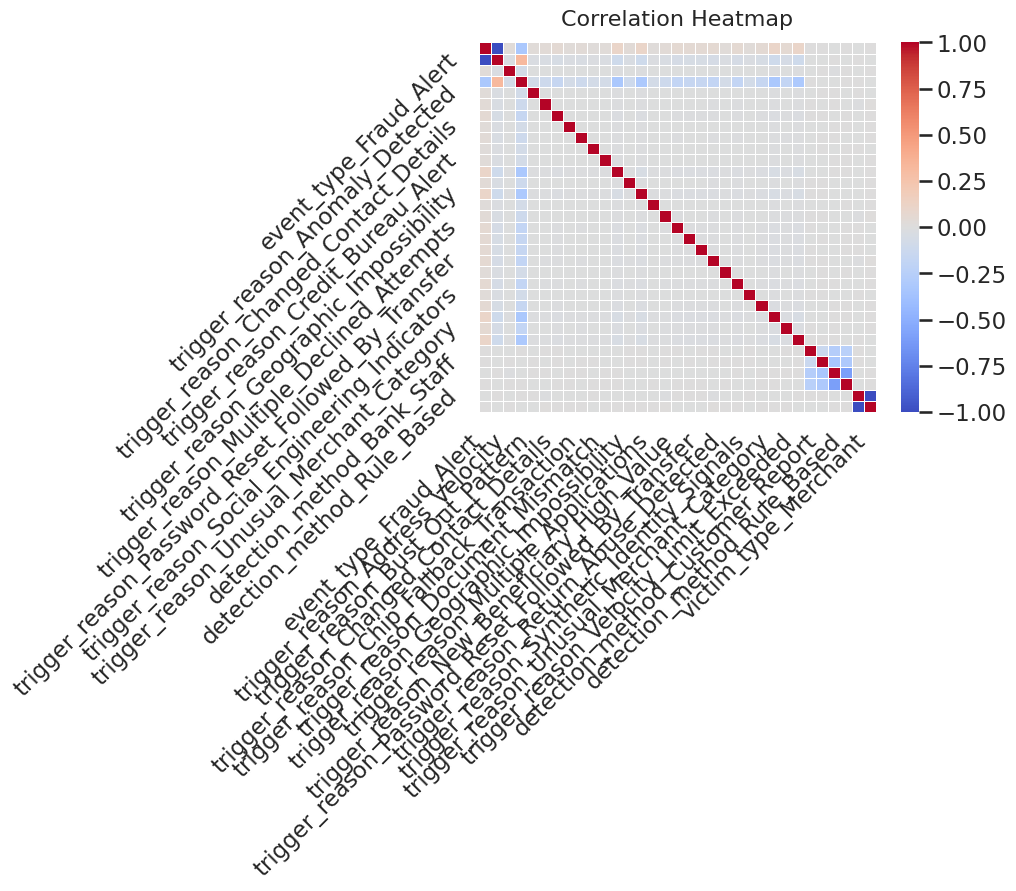

In [299]:
res = X_train_enc.corr(method='spearman')
dataplot = sns.heatmap(
    res,
    cmap='coolwarm',
    linewidths=0.5
)

dataplot.set_title('Correlation Heatmap', fontsize=16, pad=12)
dataplot.set_xticklabels(dataplot.get_xticklabels(), rotation=45, ha='right')
dataplot.set_yticklabels(dataplot.get_yticklabels(), rotation=45, va='top')
plt.savefig('correlation_matrix.png')

# PCA Analysis
- Finding the elbow of the explained variance in the data (10 components) and reducing dimensions to that

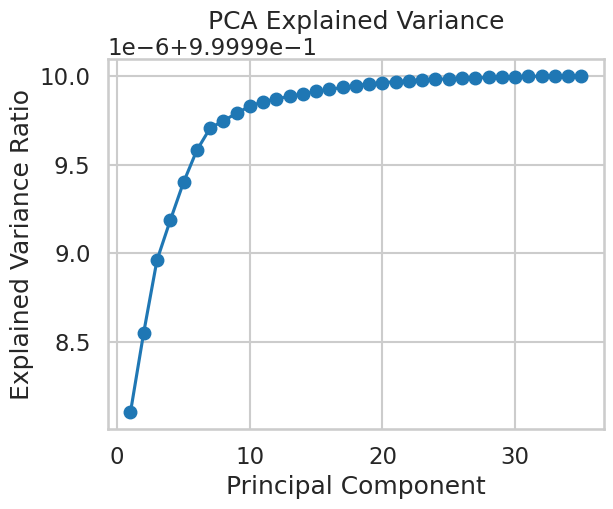

In [300]:
pca = PCA()
pca.fit(X_train_enc)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure()

plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')

plt.show()

# Ridge regression

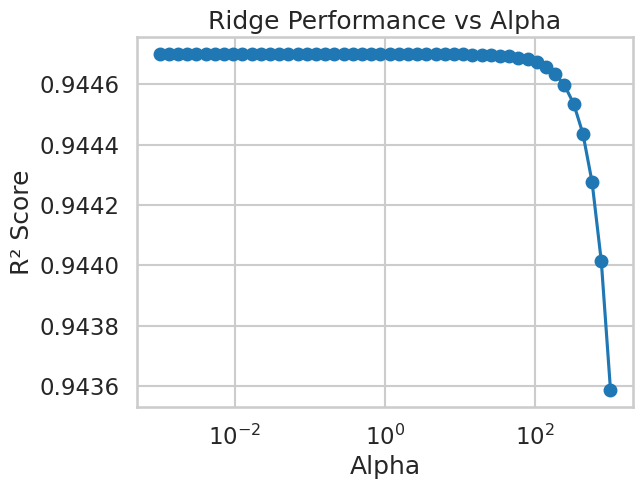

In [301]:
alphas = np.logspace(-3, 3, 50)
scores = []

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_enc, y_train_enc)
    y_pred = model.predict(X_test_enc)
    scores.append(r2_score(y_test_enc, y_pred))

plt.figure()
plt.plot(alphas, scores, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R² Score')
plt.title('Ridge Performance vs Alpha')
plt.show()

# Lasso

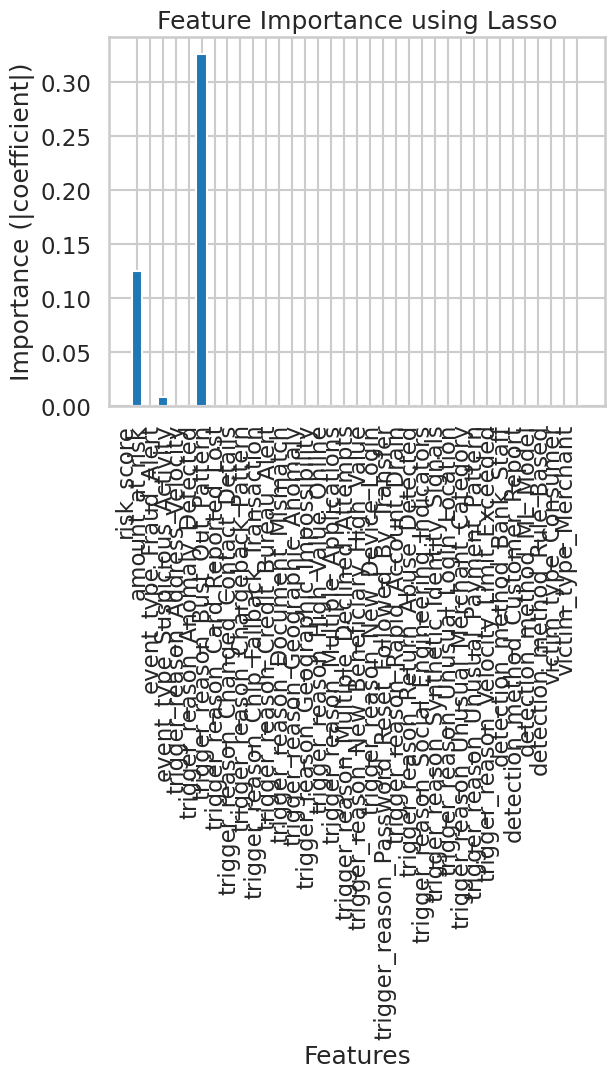

Non-zero coefficients: 4
Max coefficient: 0.3256118375561409


In [302]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_enc)

model = Lasso(alpha=0.001)
model.fit(X_scaled, y_train_enc)

# Get feature importance
importance = np.abs(model.coef_)

feature_names = X_train_enc.columns  

# Plot
plt.figure()
plt.bar(feature_names, importance)
plt.xticks(rotation=90, ha='right')
plt.xlabel('Features')
plt.ylabel('Importance (|coefficient|)')
plt.title('Feature Importance using Lasso')
plt.show()
print("Non-zero coefficients:", np.sum(model.coef_ != 0))
print("Max coefficient:", np.max(np.abs(model.coef_)))

# Linear Discriminant Analysis

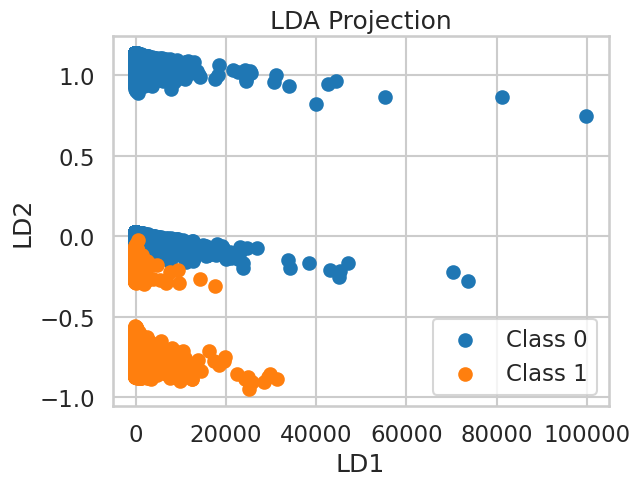

In [303]:
lda = PCA()
X_lda = lda.fit_transform(X_train_enc, y_train)


plt.figure()

for label in np.unique(y_train):
    plt.scatter(X_lda[y_train == label, 0],
                X_lda[y_train == label, 1],
                label=f'Class {label}')

plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend()
plt.title('LDA Projection')
plt.show()


In [304]:
categorical_cols = ['event_type','trigger_reason', 'detection_method', 'victim_type']
numeric_cols = ["risk_score","amount_at_risk"]
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

def make_pipeline(model):
    return Pipeline([
        ('preprocessing', preprocessor),
        ('pca', PCA(n_components=10)),
        ('classifier', model)
    ])

y = y.astype(int)

In [305]:
def heatmap(cm, title):
    sns.heatmap(cm, 
            annot=True,
            fmt='g', 
            xticklabels=['Positive','Negative'],
            yticklabels=['Positive','Negative'])
    plt.ylabel('Actual', fontsize=13)
    plt.xlabel('Prediction', fontsize=13)
    plt.title(title, fontsize=17, pad=20)
    plt.gca().xaxis.set_label_position('top') 
    plt.gca().xaxis.tick_top()

    plt.gca().figure.subplots_adjust(bottom=0.2)
    plt.show()

In [306]:
# init test df for auc-roc
test_df = pd.DataFrame({'True': y})

In [307]:
# init dict for obtaining best recall
f1_dict = {}

# Performing k fold cross validation using different model types

In [308]:
scoring = ['accuracy', 'precision', 'recall', 'f1']

def perform_k_fold(pipeline, title):
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    results = cross_validate(pipeline, X, y, cv=kf, scoring=scoring, n_jobs=-1)
    y_pred = cross_val_predict(pipeline, X, y, cv=kf)
    cm = confusion_matrix(y, y_pred)
    heatmap(cm, title)
    test_df[title] = y_pred
    print("Accuracy per fold:", results['test_accuracy'])
    print("Precision per fold:", results['test_precision'])
    print("Recall per fold:", results['test_recall'])
    f1_dict[title] = results['test_f1']
    print("F1 per fold:", results['test_f1'])

### SVC

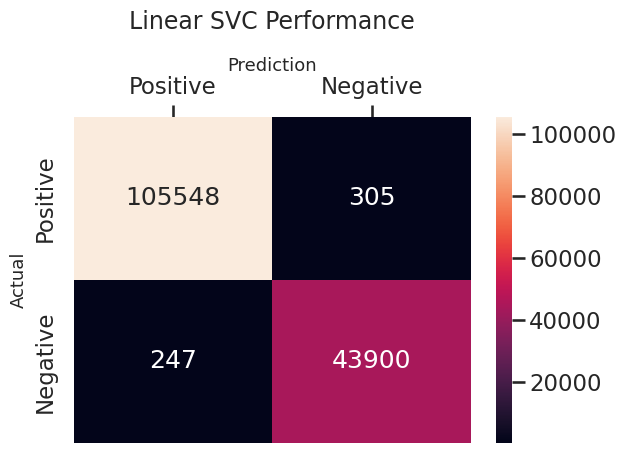

Accuracy per fold: [0.99663333 0.99656667 0.9958     0.9961     0.99646667]
Precision per fold: [0.99344188 0.99444696 0.99130631 0.99331899 0.99299277]
Recall per fold: [0.99512969 0.99388379 0.99445011 0.99343148 0.99501699]
F1 per fold: [0.99428507 0.9941653  0.99287572 0.99337523 0.99400385]


In [309]:
svc_pipeline = make_pipeline(SVC(kernel='rbf',class_weight='balanced'))
perform_k_fold(svc_pipeline, "Linear SVC Performance")

### Random forest 

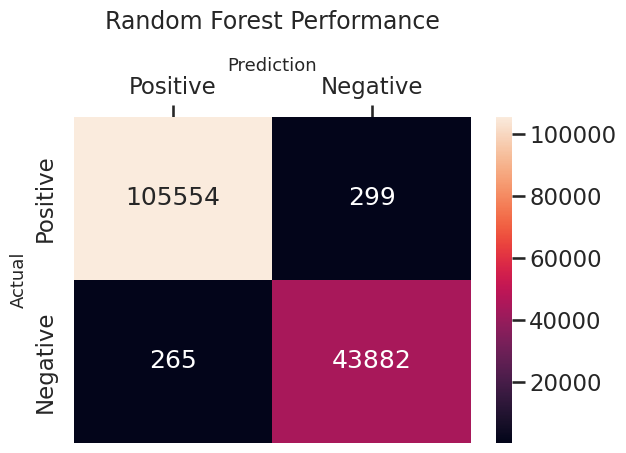

Accuracy per fold: [0.99643333 0.99663333 0.99583333 0.9962     0.9964    ]
Precision per fold: [0.9932142  0.99467241 0.99175141 0.99376841 0.99332579]
Recall per fold: [0.99467663 0.99388379 0.99411032 0.99331823 0.99445074]
F1 per fold: [0.99394488 0.99427794 0.99292946 0.99354327 0.99388795]


In [310]:
forest_classifier = make_pipeline(RandomForestClassifier(n_estimators=100, max_depth=10,class_weight='balanced'))
perform_k_fold(forest_classifier, 'Random Forest Performance')

### neural network

In [311]:
nn_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', MLPClassifier(random_state=42))
])

In [312]:
param_grid = {
    'classifier__hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__solver': ['adam', 'sgd'],
    'classifier__max_iter': [200, 300]
}

random_search = RandomizedSearchCV(
    nn_pipeline,  
    param_distributions=param_grid, 
    n_iter=10,       
    cv=5,            
    n_jobs=-1,       
    random_state=42,
    verbose=2        
)
random_search.fit(X, y)
print("Best score:", random_search.best_score_)
print("Best hyperparameters:", random_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END classifier__activation=relu, classifier__hidden_layer_sizes=(100, 50), classifier__max_iter=200, classifier__solver=adam; total time=   7.6s
[CV] END classifier__activation=relu, classifier__hidden_layer_sizes=(100, 50), classifier__max_iter=200, classifier__solver=adam; total time=   6.8s
[CV] END classifier__activation=relu, classifier__hidden_layer_sizes=(100, 50), classifier__max_iter=200, classifier__solver=adam; total time=   8.9s
[CV] END classifier__activation=relu, classifier__hidden_layer_sizes=(100, 50), classifier__max_iter=200, classifier__solver=adam; total time=  10.8s
[CV] END classifier__activation=tanh, classifier__hidden_layer_sizes=(100,), classifier__max_iter=200, classifier__solver=adam; total time=   5.9s
[CV] END classifier__activation=relu, classifier__hidden_layer_sizes=(100, 50), classifier__max_iter=200, classifier__solver=adam; total time=   9.0s
[CV] END classifier__activation=tanh, clas

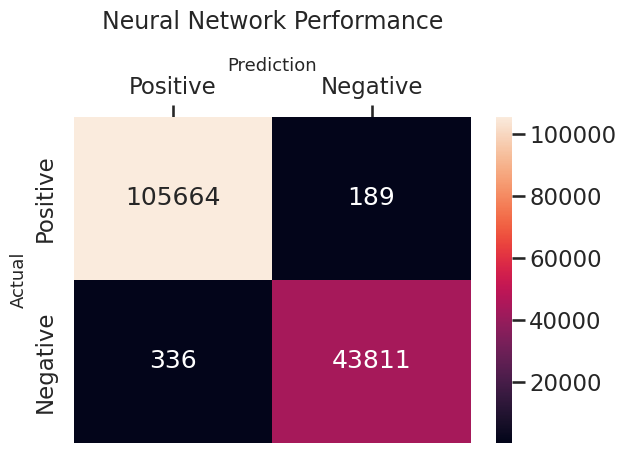

Accuracy per fold: [0.9966     0.9968     0.9961     0.99626667 0.99673333]
Precision per fold: [0.99523323 0.9968142  0.99443814 0.99613021 0.99591095]
Recall per fold: [0.99320421 0.99229811 0.99229811 0.99116648 0.99297848]
F1 per fold: [0.99421769 0.99455103 0.99336697 0.99364214 0.99444255]


In [313]:
best_nn = random_search.best_estimator_
perform_k_fold(best_nn, 'Neural Network Performance')

### Logistic regression

In [314]:
logistic_classifier = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])


In [315]:
grid_params = {
    'classifier__solver': ['saga'],  
    'classifier__penalty': ['l1'],  
    'classifier__C': [1, 10],        
    'classifier__fit_intercept': [True, False]
}
random_search = RandomizedSearchCV(
    logistic_classifier,       
    param_distributions=grid_params,  
    n_iter=10,                 
    cv=3,                     
    n_jobs=-1,                 
    random_state=42,
    verbose=2
)
random_search.fit(X, y)
print("Best score:", random_search.best_score_)
print("Best hyperparameters:", random_search.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_search.py:307: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=1, classifier__fit_intercept=True, classifier__penalty=l1, classifier__solver=saga; total time=  53.8s


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=1, classifier__fit_intercept=False, classifier__penalty=l1, classifier__solver=saga; total time=  53.5s
[CV] END classifier__C=1, classifier__fit_intercept=True, classifier__penalty=l1, classifier__solver=saga; total time=  55.8s


...

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=10, classifier__fit_intercept=False, classifier__penalty=l1, classifier__solver=saga; total time=  57.2s


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=10, classifier__fit_intercept=False, classifier__penalty=l1, classifier__solver=saga; total time=  56.5s
Best score: 0.9961333333333334
Best hyperparameters: {'classifier__solver': 'saga', 'classifier__penalty': 'l1', 'classifier__fit_intercept': True, 'classifier__C': 1}


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which 

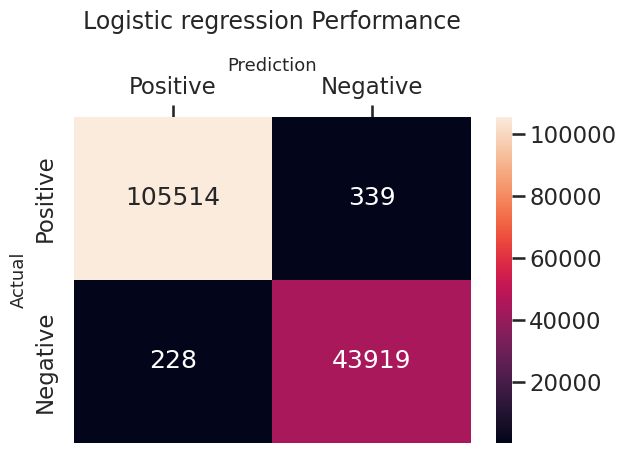

Accuracy per fold: [0.99646667 0.99663333 0.99553333 0.99613333 0.99633333]
Precision per fold: [0.99232419 0.99411232 0.98985915 0.99298484 0.9924328 ]
Recall per fold: [0.995696   0.99445011 0.99501642 0.99388448 0.99513024]
F1 per fold: [0.99400724 0.99428118 0.99243109 0.99343446 0.99377969]


In [316]:
best_regression = random_search.best_estimator_
perform_k_fold(best_regression, 'Logistic regression Performance')

### KNN

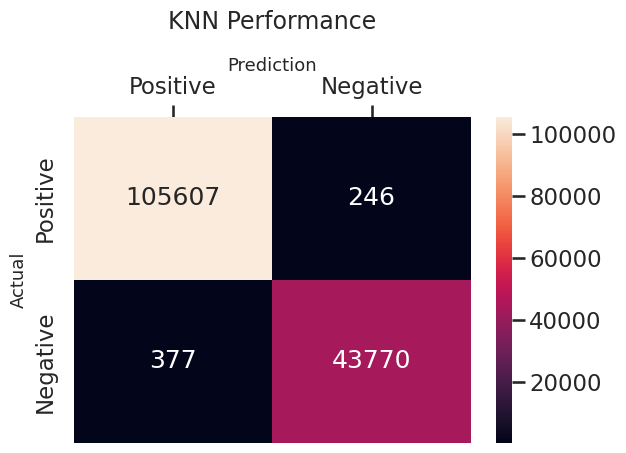

Accuracy per fold: [0.99596667 0.99623333 0.9956     0.9955     0.99593333]
Precision per fold: [0.99454793 0.99567789 0.99319496 0.99442739 0.99421112]
Recall per fold: [0.99173179 0.99150527 0.99184506 0.99026048 0.99195923]
F1 per fold: [0.99313787 0.9935872  0.99251955 0.99233956 0.9930839 ]


In [317]:
knn_classifier = make_pipeline(
    KNeighborsClassifier(
        n_neighbors=5,
        weights='distance'  
    )
)

perform_k_fold(knn_classifier, 'KNN Performance')

# Graph AUC ROC

In [318]:
test_df

,True,Linear SVC Performance,Random Forest Performance,Neural Network Performance,Logistic regression Performance,KNN Performance
0,0,0,0,0,0,0
1,1,1,1,1,1,1
2,1,1,1,1,1,1
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
149995,0,0,0,0,0,0
149996,0,0,0,0,0,0
149997,1,1,1,1,1,1
149998,0,0,0,0,0,0


In [319]:
print(test_df.columns)

Index(['True', 'Linear SVC Performance', 'Random Forest Performance',
       'Neural Network Performance', 'Logistic regression Performance',
       'KNN Performance'],
      dtype='object')


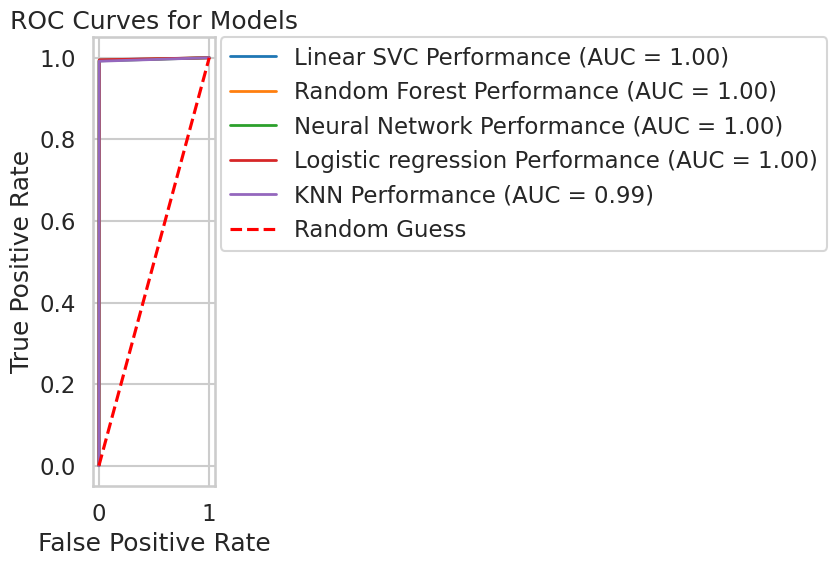

In [320]:
plt.figure(figsize=(9, 6))

models = [
    'Linear SVC Performance', 
    'Random Forest Performance',
    'Neural Network Performance', 
    'Logistic regression Performance',
    'KNN Performance'
]

for model in models:
    fpr, tpr, _ = roc_curve(test_df['True'], test_df[model])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Models')


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

# Finding our best model 

In [321]:
f1_dict

{'Linear SVC Performance': array([0.99428507, 0.9941653 , 0.99287572, 0.99337523, 0.99400385]),
 'Random Forest Performance': array([0.99394488, 0.99427794, 0.99292946, 0.99354327, 0.99388795]),
 'Neural Network Performance': array([0.99421769, 0.99455103, 0.99336697, 0.99364214, 0.99444255]),
 'Logistic regression Performance': array([0.99400724, 0.99428118, 0.99243109, 0.99343446, 0.99377969]),
 'KNN Performance': array([0.99313787, 0.9935872 , 0.99251955, 0.99233956, 0.9930839 ])}

In [322]:
averages = {model: np.mean(scores) for model, scores in f1_dict.items()}

In [323]:
best_model = max(averages, key=averages.get)
print(best_model, averages[best_model])

Neural Network Performance 0.9940440766025157


# Model Selection
- since the neural network model has the best average f1, we can choose that

In [324]:
final_model = best_nn.fit(X, y)

In [325]:
import pickle

# save
with open('fraud_classifier.pkl','wb') as f:
    pickle.dump(best_regression,f)

In [326]:
print(X)

                 event_type risk_score                 trigger_reason  \
0               Fraud_Alert      0.194               Anomaly_Detected   
1               Fraud_Alert     0.8083              High_Value_Online   
2               Fraud_Alert     0.7567             Geographic_Anomaly   
3               Fraud_Alert     0.2338               Anomaly_Detected   
4       Suspicious_Activity     0.2524               Anomaly_Detected   
...                     ...        ...                            ...   
149995          Fraud_Alert     0.2588               Anomaly_Detected   
149996          Fraud_Alert     0.4318               Anomaly_Detected   
149997          Fraud_Alert     0.6751  Social_Engineering_Indicators   
149998          Fraud_Alert     0.1584               Anomaly_Detected   
149999          Fraud_Alert      0.725      Unusual_Merchant_Category   

       amount_at_risk detection_method victim_type  
0                90.9         ML_Model    Consumer  
1               8

In [327]:
print(y)

0         0
1         1
2         1
3         0
4         0
         ..
149995    0
149996    0
149997    1
149998    0
149999    1
Name: fraud_label, Length: 150000, dtype: int64


In [2]:
!git init
!git add .
!git commit -m "initial commit"

Reinitialized existing Git repository in /home/jovyan/.git/
fatal: detected dubious ownership in repository at '/home/jovyan'
To add an exception for this directory, call:

	git config --global --add safe.directory /home/jovyan
fatal: detected dubious ownership in repository at '/home/jovyan'
To add an exception for this directory, call:

	git config --global --add safe.directory /home/jovyan
